# esmDMS Simulation!!

Benchmarking out inference methods with perfect data!

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rc
from numpy.linalg import inv 
from sklearn import linear_model 
import stan
from esmdmsfunctions import *

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [91]:
rc('text', usetex=True)
pd.set_option('display.max_columns', 100)
pwd = os.getcwd()

init_pop = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')

init_pop = init_pop[init_pop['Embeddings'].notna()].reset_index(drop=True)

In [92]:
# Combine the prenums and postnums of any entries with the same potein sequence
init_pop['PreNums'] = init_pop['PreNums'].apply(lambda x: np.array(x))
init_pop['PostNums'] = init_pop['PostNums'].apply(lambda x: np.array(x))
init_pop_grouped = init_pop.groupby('ProteinSequence').agg({
    'PreNums': lambda x: np.sum(x.tolist(), axis=0),
    'PostNums': lambda x: np.sum(x.tolist(), axis=0),
    'Embeddings': 'first'
}).reset_index()

In [93]:
init_pop_grouped

,ProteinSequence,PreNums,PostNums,Embeddings
0,A*NLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[39, 47, 53]","[8, 5, 6]","[[-0.031513277, -0.027529575, -0.043846164, -0..."
1,AANLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[16, 13, 18]","[9, 6, 10]","[[-0.03163178, -0.02769079, -0.04372052, -0.01..."
2,ACNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[7, 6, 6]","[6, 2, 5]","[[-0.031665795, -0.027563317, -0.043822058, -0..."
3,ADNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[14, 8, 3]","[2, 6, 6]","[[-0.03162248, -0.027495803, -0.043818824, -0...."
4,AENLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[29, 46, 34]","[72, 68, 93]","[[-0.031206096, -0.027565997, -0.043747563, -0..."
...,...,...,...,...
13167,GGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[0, 2, 0]","[0, 0, 1]","[[-0.031604197, -0.027621143, -0.043950938, -0..."
13168,PGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[1, 0, 0]","[1, 1, 1]","[[-0.03163283, -0.027663246, -0.043426607, -0...."
13169,SGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[2, 7, 0]","[1, 5, 3]","[[-0.031612042, -0.02763081, -0.043894112, -0...."
13170,TGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[110, 164, 94]","[114, 173, 207]","[[-0.031634934, -0.027693663, -0.043913726, -0..."


In [94]:
np.random.seed(0)

# Make dataframes for each of the three replicates
replicate_dfs = []
n_reps = 3
for rep in range(n_reps):
    df_rep = init_pop_grouped.copy()
    df_rep['PreNums'] = df_rep['PreNums'].apply(lambda x: x[rep])
    df_rep['PostNums'] = df_rep['PostNums'].apply(lambda x: x[rep])
    df_rep = df_rep.drop(columns=['ProteinSequence'])
    replicate_dfs.append(df_rep)
replicate_dfs[0]

,PreNums,PostNums,Embeddings
0,39,8,"[[-0.031513277, -0.027529575, -0.043846164, -0..."
1,16,9,"[[-0.03163178, -0.02769079, -0.04372052, -0.01..."
2,7,6,"[[-0.031665795, -0.027563317, -0.043822058, -0..."
3,14,2,"[[-0.03162248, -0.027495803, -0.043818824, -0...."
4,29,72,"[[-0.031206096, -0.027565997, -0.043747563, -0..."
...,...,...,...
13167,0,0,"[[-0.031604197, -0.027621143, -0.043950938, -0..."
13168,1,1,"[[-0.03163283, -0.027663246, -0.043426607, -0...."
13169,2,1,"[[-0.031612042, -0.02763081, -0.043894112, -0...."
13170,110,114,"[[-0.031634934, -0.027693663, -0.043913726, -0..."


In [95]:
num_layers = replicate_dfs[0]['Embeddings'][0].shape[0]

# decompose the embeddings for each replicate and layer
decomposed_dfs = []
for rep_df in replicate_dfs:
    decomposed_df = rep_df[['PreNums', 'PostNums']].copy()
    
    for layer in range(num_layers):
        decomposed_df[f'Layer{layer}'] = rep_df['Embeddings'].apply(lambda x: x[layer])
    decomposed_dfs.append(decomposed_df)

In [96]:
for layer in range(num_layers):
    print(decomposed_dfs[0][f'Layer{layer}'].iloc[0].shape) # ALL (640,)

(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)


In [97]:
# Let's choose Layer 12 for funzies
selected_layer = 12
df_selection = pd.DataFrame()
for i, decomposed_df in enumerate(decomposed_dfs):
    df_selection[f'Rep{i+1}_PreNums'] = decomposed_df['PreNums']
    df_selection[f'Rep{i+1}_PostNums'] = decomposed_df['PostNums']
df_selection[f'Embedding'] = decomposed_df[f'Layer{selected_layer}']


In [98]:
df_selection

,Rep1_PreNums,Rep1_PostNums,Rep2_PreNums,Rep2_PostNums,Rep3_PreNums,Rep3_PostNums,Embedding
0,39,8,47,5,53,6,"[-0.59095, -0.20893419, -1.074131, -0.5501634,..."
1,16,9,13,6,18,10,"[-0.5835699, -0.20366529, -1.0667843, -0.55543..."
2,7,6,6,2,6,5,"[-0.59919953, -0.22746255, -1.0731624, -0.5670..."
3,14,2,8,6,3,6,"[-0.59044176, -0.22718638, -1.086812, -0.55924..."
4,29,72,46,68,34,93,"[-0.5861342, -0.23495646, -1.0848683, -0.56606..."
...,...,...,...,...,...,...,...
13167,0,0,2,0,0,1,"[-0.58649033, -0.22007006, -1.0617292, -0.5396..."
13168,1,1,0,1,0,1,"[-0.594706, -0.20239507, -1.0794948, -0.540265..."
13169,2,1,7,5,0,3,"[-0.5857174, -0.21249211, -1.075183, -0.542879..."
13170,110,114,164,173,94,207,"[-0.57897925, -0.21528694, -1.0847609, -0.5478..."


In [73]:
# Now, let's calculate the fitness for each variant based on its embedding and the selection coefficients
def calculate_fitness_exp(embedidng, selection_coefficients):
    return np.exp(np.dot(embedidng, selection_coefficients))

def calculate_fitness_plus1(embedidng, selection_coefficients):
    return 1 + np.dot(embedidng, selection_coefficients)

def simulate_generation_multinomial(current_counts, fitnesses):
    population_size = np.sum(current_counts)
    total_fitness = np.sum(current_counts * fitnesses)
    probabilities = (current_counts * fitnesses) / total_fitness
    # if a probability is below 0, set it to zero
    # if a probability is above 1, set it to 1
    probabilities = np.clip(probabilities, 0, 1)
    next_counts = np.random.multinomial(population_size, probabilities)
    return next_counts # Check if output is a different scale


In [100]:
# Generate some random selection coefficients for the 640 dimensions
np.random.seed(42)
selection_coefficients = np.random.normal(loc=0.0, scale=0.1, size=640)

embeddings = np.vstack(df_selection['Embedding'].values)
fitnesses_exp = calculate_fitness_exp(embeddings, selection_coefficients)
fitnesses_plus1 = calculate_fitness_plus1(embeddings, selection_coefficients)

start_counts1 = df_selection["Rep1_PreNums"].values
start_counts2 = df_selection["Rep2_PreNums"].values
start_counts3 = df_selection["Rep3_PreNums"].values

In [101]:
# Running the Simulation

generation_counts = [[start_counts1, start_counts2, start_counts3]]
n_gens = 30

use_fit = fitnesses_plus1

for gen in range(n_gens):
    gen_counts = generation_counts[-1]
    this_gen = []
    for rep in range(n_reps):
        # Generate a new set of generation_counts: [rep1_counts, rep2_counts, rep3_counts]
        # append them to the generation_counts list
        rep_counts = gen_counts[rep]
        next_counts = simulate_generation_multinomial(rep_counts, use_fit)
        this_gen.append(next_counts)
    generation_counts.append(this_gen)
        

In [58]:
def get_df_selection(random_seed=42, selected_layer=12):
    """Get the starting informatin for the simulation,
    i.e. the layer dataframe and the initial counts for each replicate."""
    # Set initial variables
    rc('text', usetex=True)
    pd.set_option('display.max_columns', 100)
    pwd = os.getcwd()
    init_pop = get_unique_df(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')
    np.random.seed(random_seed)
    n_reps = 3

    # Make dataframes for each of the three replicates
    replicate_dfs = []
    for rep in range(n_reps):
        df_rep = init_pop.copy()
        df_rep['PreNums'] = df_rep['PreNums'].apply(lambda x: x[rep])
        df_rep['PostNums'] = df_rep['PostNums'].apply(lambda x: x[rep])
        df_rep = df_rep.drop(columns=['ProteinSequence'])
        replicate_dfs.append(df_rep)
    replicate_dfs[0]
    num_layers = replicate_dfs[0]['Embeddings'][0].shape[0]

    # decompose the embeddings for each replicate and layer
    decomposed_dfs = []
    for rep_df in replicate_dfs:
        decomposed_df = rep_df[['PreNums', 'PostNums']].copy()
        
        for layer in range(num_layers):
            decomposed_df[f'Layer{layer}'] = rep_df['Embeddings'].apply(lambda x: x[layer])
        decomposed_dfs.append(decomposed_df)

    df_selection = pd.DataFrame()
    for i, decomposed_df in enumerate(decomposed_dfs):
        df_selection[f'Rep{i+1}_PreNums'] = decomposed_df['PreNums']
        df_selection[f'Rep{i+1}_PostNums'] = decomposed_df['PostNums']
    df_selection[f'Embedding'] = decomposed_df[f'Layer{selected_layer}']
    
    # Generate some random selection coefficients for the 640 dimensions
    """selection_coefficients = np.random.normal(loc=0.0, scale=0.1, size=640)
    selection_coefficients = np.abs(selection_coefficients)  # Ensure non-negative for this example

    embeddings = np.vstack(df_selection['Embedding'].values)
    fitnesses_exp = calculate_fitness_exp(embeddings, selection_coefficients)
    fitnesses_plus1 = calculate_fitness_plus1(embeddings, selection_coefficients)"""

    start_counts1 = df_selection["Rep1_PreNums"].values
    start_counts2 = df_selection["Rep2_PreNums"].values
    start_counts3 = df_selection["Rep3_PreNums"].values
    
    return df_selection, (start_counts1, start_counts2, start_counts3)


def run_simulation(selection_coefficients, initial_counts, n_gens=30):
    embeddings = np.vstack(df_selection['Embedding'].values)
    fitnesses = calculate_fitness_exp(embeddings, selection_coefficients)
    
    generation_counts = [initial_counts]
    n_reps = 3
    
    for gen in range(n_gens):
        gen_counts = generation_counts[-1]
        this_gen = []
        for rep in range(n_reps):
            rep_counts = gen_counts[rep]
            next_counts = simulate_generation_multinomial(rep_counts, fitnesses)
            this_gen.append(next_counts)
        generation_counts.append(this_gen)
    
    return generation_counts

In [59]:
# Now, calculate selectiion_coefficitents from the generational counts

import popDMS
import pandas as pd
import pickle
from importlib import reload

# reload popDMS
reload(popDMS)


def simulation_df_transfer(df_selection, generation_counts):
    #["Generation", "Embedding", "Frequency", "Replicate"]
    emb_vals = df_selection["Embedding"].values
    #generation counts format [[gen1data], [gen2data],...]
    data_list = []
    for gen, gen_data in enumerate(generation_counts):
        for rep, rep_data in enumerate(gen_data):
            for i, count in enumerate(rep_data):
                data_list.append({
                    "Generation": gen,
                    "Embedding": emb_vals[i],
                    "Frequency": count,
                    "Replicate": rep + 1
                })
    return pd.DataFrame(data_list)

def run_inference_calcs_sims(df_selection, generation_counts, output_path,
                             save_output=False):
    """Run the inference calculations:
    WHOLE PIPELINE FROM READING IN EMBEDDINGS DATAFRAME
    """
    inference_df = simulation_df_transfer(df_selection, generation_counts)
    
    if save_output:
        # make directory
        if not os.path.exists(output_path):
            os.makedirs(output_path)
        # save inference_df
        inference_df.to_pickle(output_path + 'inference_df.pkl')
        print(f"SAVED INFERENCE DF TO {output_path}")
    
       
    data = popDMS.mini_infer_independent_esm(inference_df, n_replicates=3)
    return data # data = [dx, icov, s, s_joint, sel_data, gamma_opt, x_array]


SAVED INFERENCE DF TO /Users/dylanwells/CodingProjects/popDMS/esmDMS/simulations/
corrs_list: [[np.float64(0.7703766753674915), np.float64(0.46015609531079216), np.float64(0.8543141397340184)], [np.float64(0.7703766757360184), np.float64(0.4601560960072951), np.float64(0.8543141398513929)], [np.float64(0.7703766761693571), np.float64(0.4601560968262796), np.float64(0.8543141399893985)], [np.float64(0.7703766766789), np.float64(0.46015609778927835), np.float64(0.854314140151649)], [np.float64(0.770376677278062), np.float64(0.4601560989216247), np.float64(0.8543141403424968)], [np.float64(0.7703766779825597), np.float64(0.46015610025308984), np.float64(0.8543141405668444)], [np.float64(0.7703766788109635), np.float64(0.4601561018186907), np.float64(0.8543141408306801)], [np.float64(0.7703766797850315), np.float64(0.4601561036596106), np.float64(0.854314141140893)], [np.float64(0.7703766809303981), np.float64(0.46015610582424693), np.float64(0.8543141415056685)], [np.float64(0.77037668227

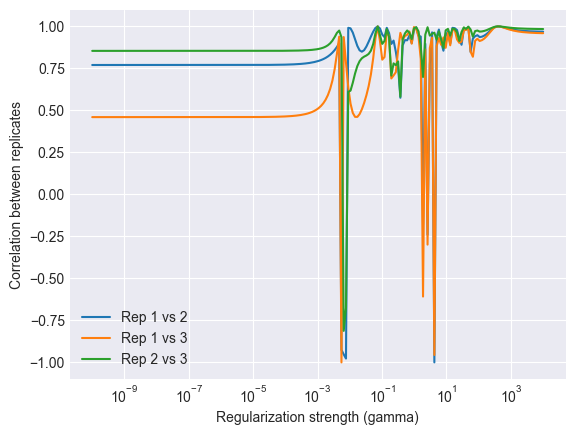

Found best regularization strength gamma = 2.8e+02, R = 0.99


In [103]:
test_path = pwd + "/simulations/"
plt.rcParams['text.usetex'] = False
test = run_inference_calcs_sims(df_selection, generation_counts, test_path)

In [104]:
# data = [dx, icov, s, s_joint, sel_data, gamma_opt, x_array]
found_sel_coeffs = test[2]


print(selection_coefficients.shape)
print(found_sel_coeffs.shape)

(640,)
(3, 640)


(640,) (640,)
(640,) (640,)
(640,) (640,)


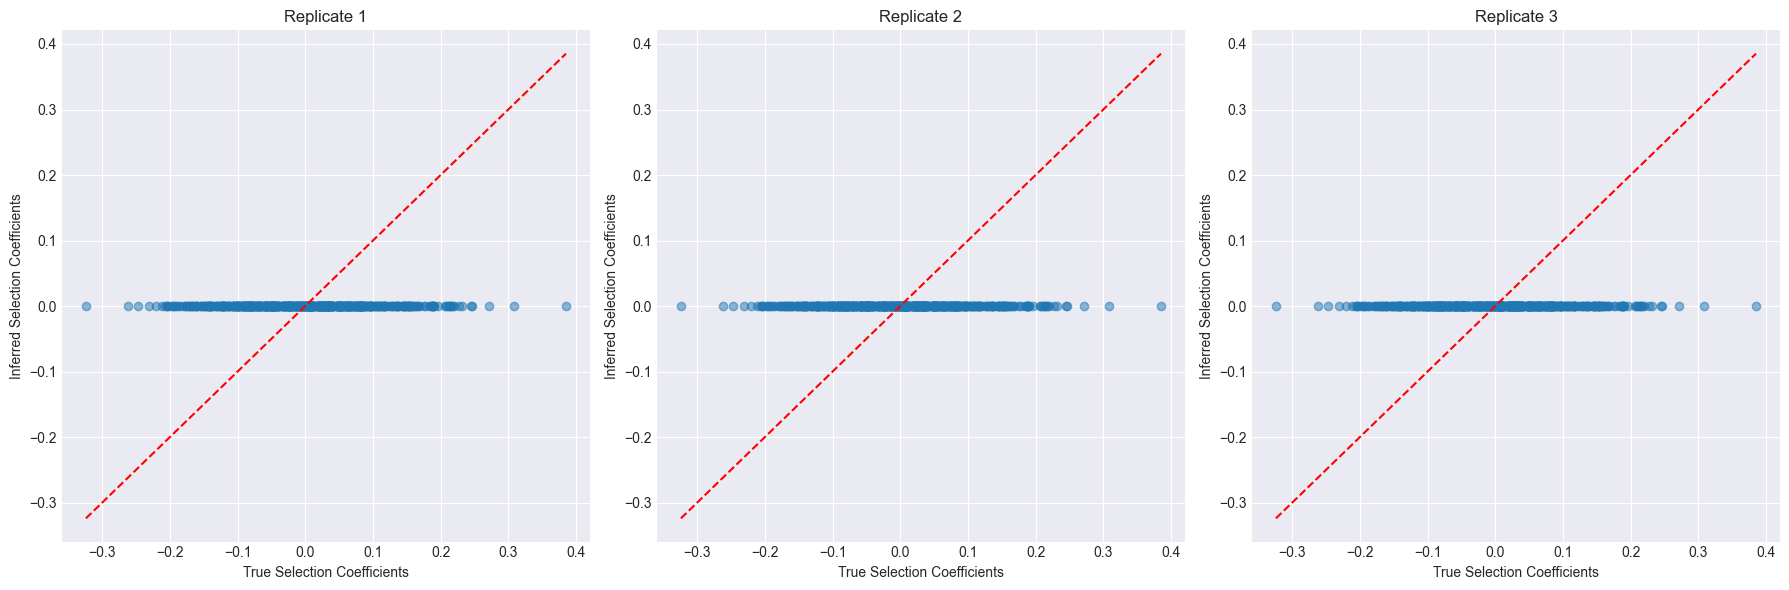

In [105]:
# Plot the true vs inferred selection coefficients for all three replicates on 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))


plt.style.use('seaborn-v0_8-darkgrid')
for rep in range(3):
    x = selection_coefficients
    y = found_sel_coeffs[rep]
    print(x.shape, y.shape)
    
    
    axs[rep].scatter(x, y, alpha=0.5)
    axs[rep].set_title(f'Replicate {rep + 1}')
    axs[rep].set_xlabel('True Selection Coefficients')
    axs[rep].set_ylabel('Inferred Selection Coefficients')
    axs[rep].plot([min(selection_coefficients), max(selection_coefficients)],
                  [min(selection_coefficients), max(selection_coefficients)],
                  color='red', linestyle='--')
plt.tight_layout()
plt.show()




Pearson correlation between Replicate 1 and Replicate 2: 0.990
Pearson correlation between Replicate 1 and Replicate 3: 0.987
Pearson correlation between Replicate 2 and Replicate 3: 0.995


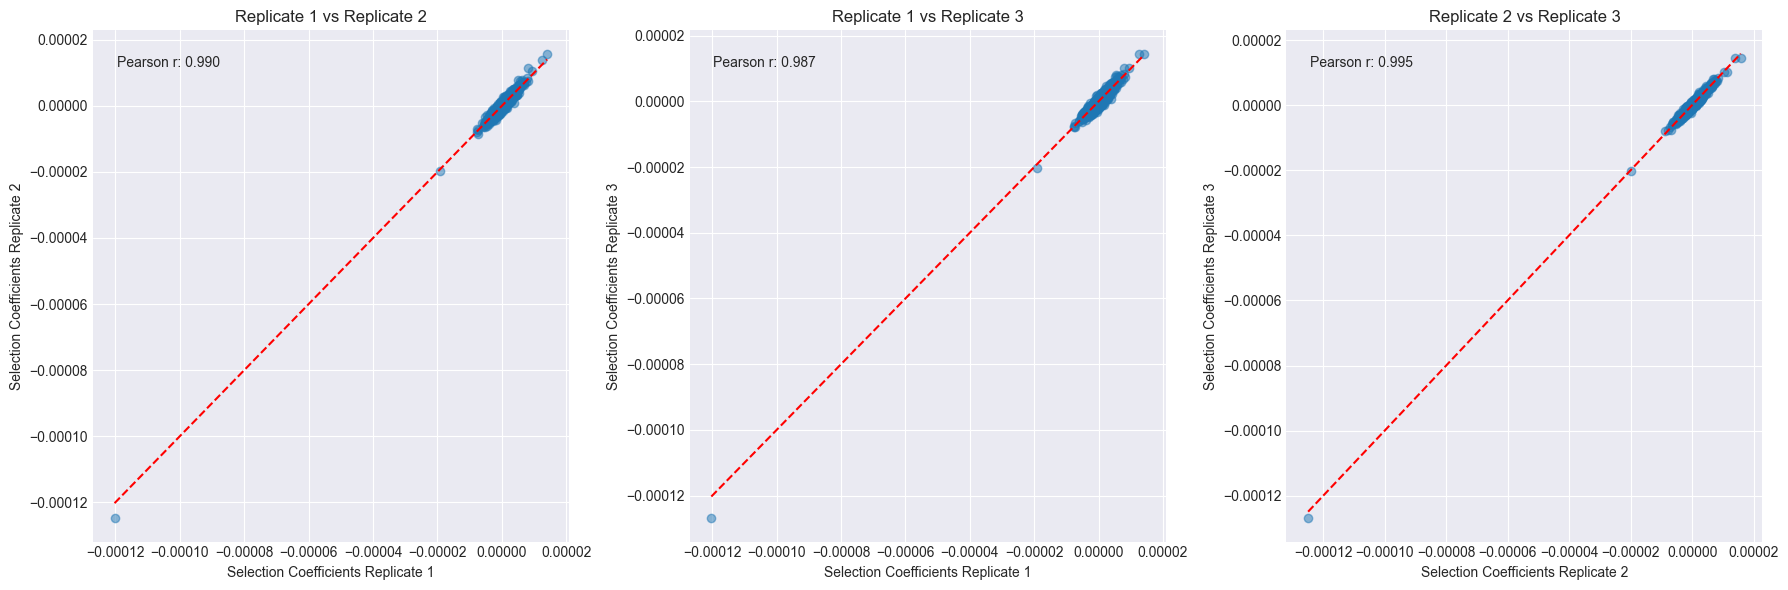

In [118]:
# Plot the selection coefficients for the three replicates against each ohter
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')
rep_pairs = [(0, 1), (0, 2), (1, 2)]
for i, (rep1, rep2) in enumerate(rep_pairs):
    x = found_sel_coeffs[rep1]
    y = found_sel_coeffs[rep2]
    # z normalize
    #x = (x - np.mean(x)) / np.std(x)
    #y = (y - np.mean(y)) / np.std(y)
    
    r_pearson = np.corrcoef(x, y)[0, 1]
    
    print(f'Pearson correlation between Replicate {rep1 + 1} and Replicate {rep2 + 1}: {r_pearson:.3f}')
    
    axs[i].scatter(x, y, alpha=0.5)
    axs[i].set_title(f'Replicate {rep1 + 1} vs Replicate {rep2 + 1}')
    axs[i].set_xlabel(f'Selection Coefficients Replicate {rep1 + 1}')
    axs[i].set_ylabel(f'Selection Coefficients Replicate {rep2 + 1}')
    axs[i].plot([min(x), max(x)],
                [min(x), max(x)],
                color='red', linestyle='--')
    # Add the pearson scorei n top left
    axs[i].text(0.05, 0.95, f'Pearson r: {r_pearson:.3f}',
                transform=axs[i].transAxes,
                verticalalignment='top')
plt.tight_layout()




Pearson correlation between Replicate 1 and Replicate 2: 0.990
Pearson correlation between Replicate 1 and Replicate 3: 0.987
Pearson correlation between Replicate 2 and Replicate 3: 0.995


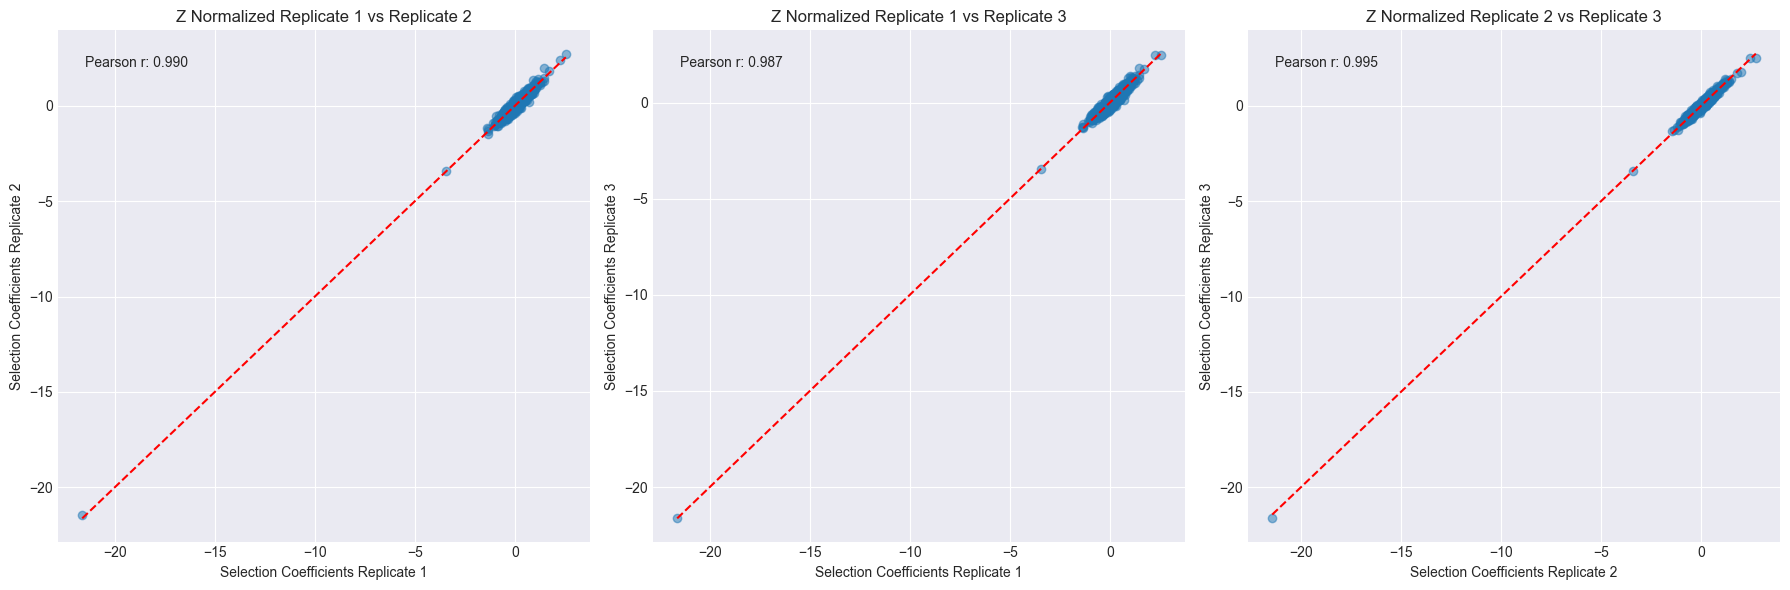

In [119]:
# Plot the selection coefficients for the three replicates against each ohter
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')
rep_pairs = [(0, 1), (0, 2), (1, 2)]
for i, (rep1, rep2) in enumerate(rep_pairs):
    x = found_sel_coeffs[rep1]
    y = found_sel_coeffs[rep2]
    # z normalize
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    
    r_pearson = np.corrcoef(x, y)[0, 1]
    
    print(f'Pearson correlation between Replicate {rep1 + 1} and Replicate {rep2 + 1}: {r_pearson:.3f}')
    
    axs[i].scatter(x, y, alpha=0.5)
    axs[i].set_title(f'Z Normalized Replicate {rep1 + 1} vs Replicate {rep2 + 1}')
    axs[i].set_xlabel(f'Selection Coefficients Replicate {rep1 + 1}')
    axs[i].set_ylabel(f'Selection Coefficients Replicate {rep2 + 1}')
    axs[i].plot([min(x), max(x)],
                [min(x), max(x)],
                color='red', linestyle='--')
    # Add the pearson scorei n top left
    axs[i].text(0.05, 0.95, f'Pearson r: {r_pearson:.3f}',
                transform=axs[i].transAxes,
                verticalalignment='top')
plt.tight_layout()




## Simulate other methods and compare

In [56]:
# Simulate other methods

def other_methods(df_selection, generation_counts, generation=-1):
    """Find the enrichment ratio, log ratio, and log enrichment"""
    first_gen = generation_counts[0]
    last_gen = generation_counts[generation]
    
    enrichments = []
    log_ratios = []
    #log_enrichments = []
    
    embeddings = np.vstack(df_selection['Embedding'].values)
    
    for rep in range(len(first_gen)):
        start_counts = first_gen[rep]
        end_counts = last_gen[rep]
        
        embedding_avg_before = np.sum(embeddings.T * start_counts, axis=1) / np.sum(start_counts)
        embedding_avg_after = np.sum(embeddings.T * end_counts, axis=1) / np.sum(end_counts)
        
        
        embedding_sum = np.sum(embedding_avg_before) + np.sum(embedding_avg_after) / 2
        
        enrichment = (embedding_avg_after / embedding_avg_before) / embedding_sum
        
        log_ratio = np.log((embedding_avg_after / embedding_avg_before) / embedding_sum)
        
        #log_enrichment = np.log(enrichment)
        
        log_ratios.append(log_ratio)
        enrichments.append(enrichment)
        
    return np.array(enrichments), np.array(log_ratios) #, np.array(log_enrichments)


In [129]:
#found_sel_coeffs
enrichments, log_ratios = other_methods(df_selection, generation_counts, generation=-1)
enrichments.shape, log_ratios.shape

((3, 640), (3, 640))

Pearson correlation between Replicate 1 and Replicate 2: 0.990
Pearson correlation between Replicate 1 and Replicate 3: 0.987
Pearson correlation between Replicate 2 and Replicate 3: 0.995
Pearson correlation between Replicate 1 and Replicate 2: 0.777
Pearson correlation between Replicate 1 and Replicate 3: 0.396
Pearson correlation between Replicate 2 and Replicate 3: 0.817
Pearson correlation between Replicate 1 and Replicate 2: 0.741
Pearson correlation between Replicate 1 and Replicate 3: 0.384
Pearson correlation between Replicate 2 and Replicate 3: 0.836


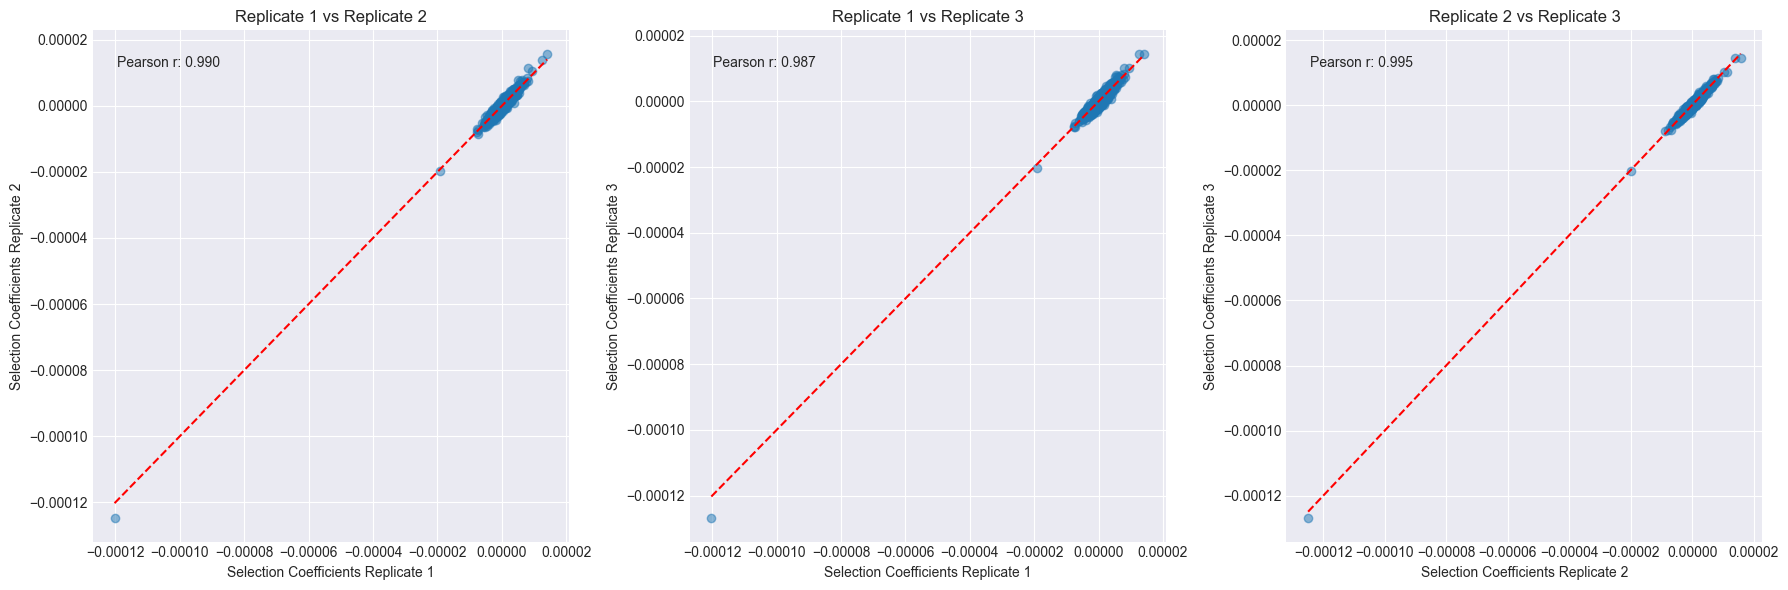

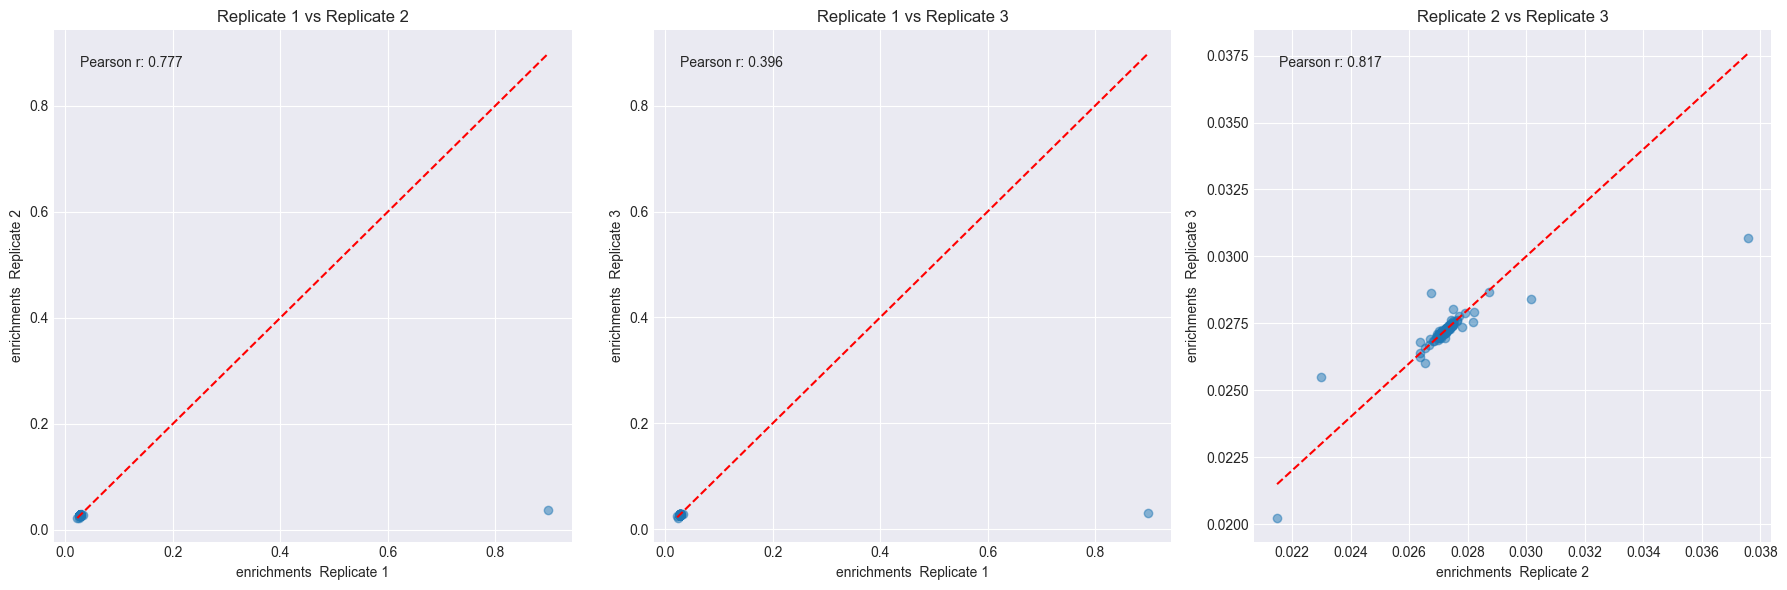

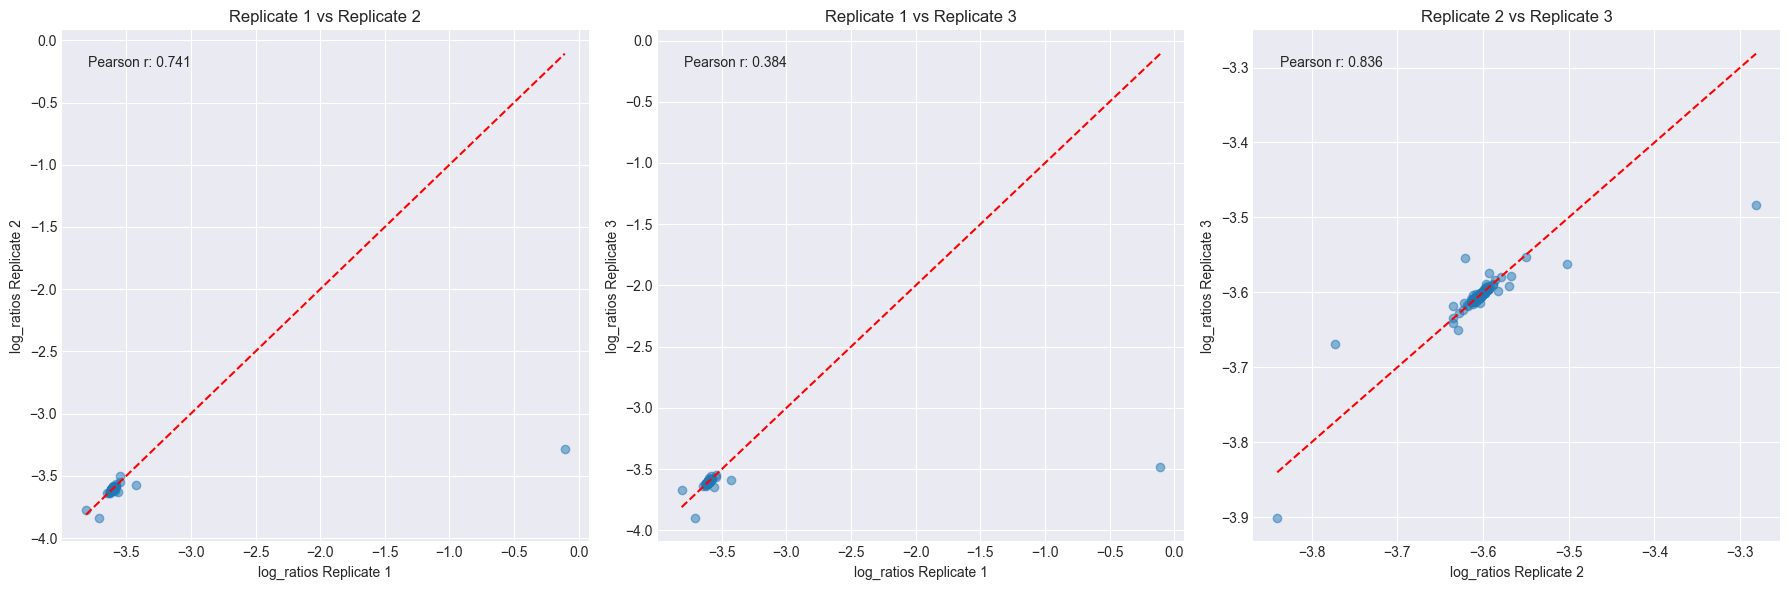

In [130]:
# Plot the selection coefficients for the three replicates against each ohter
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')
rep_pairs = [(0, 1), (0, 2), (1, 2)]
for i, (rep1, rep2) in enumerate(rep_pairs):
    x = found_sel_coeffs[rep1]
    y = found_sel_coeffs[rep2]
    # z normalize
    #x = (x - np.mean(x)) / np.std(x)
    #y = (y - np.mean(y)) / np.std(y)
    
    r_pearson = np.corrcoef(x, y)[0, 1]
    
    print(f'Pearson correlation between Replicate {rep1 + 1} and Replicate {rep2 + 1}: {r_pearson:.3f}')
    
    axs[i].scatter(x, y, alpha=0.5)
    axs[i].set_title(f'Replicate {rep1 + 1} vs Replicate {rep2 + 1}')
    axs[i].set_xlabel(f'Selection Coefficients Replicate {rep1 + 1}')
    axs[i].set_ylabel(f'Selection Coefficients Replicate {rep2 + 1}')
    axs[i].plot([min(x), max(x)],
                [min(x), max(x)],
                color='red', linestyle='--')
    # Add the pearson scorei n top left
    axs[i].text(0.05, 0.95, f'Pearson r: {r_pearson:.3f}',
                transform=axs[i].transAxes,
                verticalalignment='top')
plt.tight_layout()

# Plot the selection coefficients for the three replicates against each ohter
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')
rep_pairs = [(0, 1), (0, 2), (1, 2)]
for i, (rep1, rep2) in enumerate(rep_pairs):
    x = enrichments[rep1]
    y = enrichments[rep2]
    # z normalize
    #x = (x - np.mean(x)) / np.std(x)
    #y = (y - np.mean(y)) / np.std(y)
    
    r_pearson = np.corrcoef(x, y)[0, 1]
    
    print(f'Pearson correlation between Replicate {rep1 + 1} and Replicate {rep2 + 1}: {r_pearson:.3f}')
    
    axs[i].scatter(x, y, alpha=0.5)
    axs[i].set_title(f'Replicate {rep1 + 1} vs Replicate {rep2 + 1}')
    axs[i].set_xlabel(f'enrichments  Replicate {rep1 + 1}')
    axs[i].set_ylabel(f'enrichments  Replicate {rep2 + 1}')
    axs[i].plot([min(x), max(x)],
                [min(x), max(x)],
                color='red', linestyle='--')
    # Add the pearson scorei n top left
    axs[i].text(0.05, 0.95, f'Pearson r: {r_pearson:.3f}',
                transform=axs[i].transAxes,
                verticalalignment='top')
plt.tight_layout()


# Plot the selection coefficients for the three replicates against each ohter
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')
rep_pairs = [(0, 1), (0, 2), (1, 2)]
for i, (rep1, rep2) in enumerate(rep_pairs):
    x = log_ratios[rep1]
    y = log_ratios[rep2]
    # z normalize
    #x = (x - np.mean(x)) / np.std(x)
    #y = (y - np.mean(y)) / np.std(y)
    
    r_pearson = np.corrcoef(x, y)[0, 1]
    
    print(f'Pearson correlation between Replicate {rep1 + 1} and Replicate {rep2 + 1}: {r_pearson:.3f}')
    
    axs[i].scatter(x, y, alpha=0.5)
    axs[i].set_title(f'Replicate {rep1 + 1} vs Replicate {rep2 + 1}')
    axs[i].set_xlabel(f'log_ratios Replicate {rep1 + 1}')
    axs[i].set_ylabel(f'log_ratios Replicate {rep2 + 1}')
    axs[i].plot([min(x), max(x)],
                [min(x), max(x)],
                color='red', linestyle='--')
    # Add the pearson scorei n top left
    axs[i].text(0.05, 0.95, f'Pearson r: {r_pearson:.3f}',
                transform=axs[i].transAxes,
                verticalalignment='top')
plt.tight_layout()







In [61]:
# Lets run the whole simulation at every layer and calculate the average pearson r at every generation
layer_pearson_results = {}
n_layers = 31
n_gens = 10
n_reps = 3

for layer in range(n_layers):
    print(f"Running layer {layer}...")
    df_selection, initial_counts = get_df_selection(random_seed=42, selected_layer=layer)
    
    # Generate some random selection coefficients for the 640 dimensions
    np.random.seed(42)
    selection_coefficients = np.random.normal(loc=0.0, scale=0.1, size=640)
    #selection_coefficients = np.abs(selection_coefficients)  # Ensure non-negative for this example
    
    print("Running simulation...")
    generation_counts = run_simulation(selection_coefficients, initial_counts, n_gens=30)
    
    layer_results = []
    
    for gen in range(1, n_gens + 1):
        print(f"  Analyzing generation {gen}...")
        test_path = pwd + f"/simulations/layer_{layer}_gen_{gen}/"
        data = run_inference_calcs_sims(df_selection, generation_counts[:gen + 1], test_path)
        found_sel_coeffs = data[2]
        
        # Calculate pearson r for each replicate comparison
        rep_pearsons = []
        for rep1 in range(3):
            for rep2 in range(rep1 + 1, 3):
                x = found_sel_coeffs[rep1]
                y = found_sel_coeffs[rep2]
                r_pearson = np.corrcoef(x, y)[0, 1]
                rep_pearsons.append(r_pearson)
        
        
        layer_results.append(np.mean(rep_pearsons))
    
    layer_pearson_results[layer] = layer_results

Running layer 0...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 2...
  Analyzing generation 3...
  Analyzing generation 4...
  Analyzing generation 5...
  Analyzing generation 6...
  Analyzing generation 7...
  Analyzing generation 8...
  Analyzing generation 9...
  Analyzing generation 10...
Running layer 1...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 2...
  Analyzing generation 3...
  Analyzing generation 4...
  Analyzing generation 5...
  Analyzing generation 6...
  Analyzing generation 7...
  Analyzing generation 8...
  Analyzing generation 9...
  Analyzing generation 10...
Running layer 2...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 2...
  Analyzing generation 3...
  Analyzing generation 4...
  Analyzing generation 5...
  Analyzing generation 6...
  Analyzing generation 7...
  Analyzing generation 8...
  Analyzing generation 9...
  Analyzing generation 10...
Running layer 3...
Running simulat

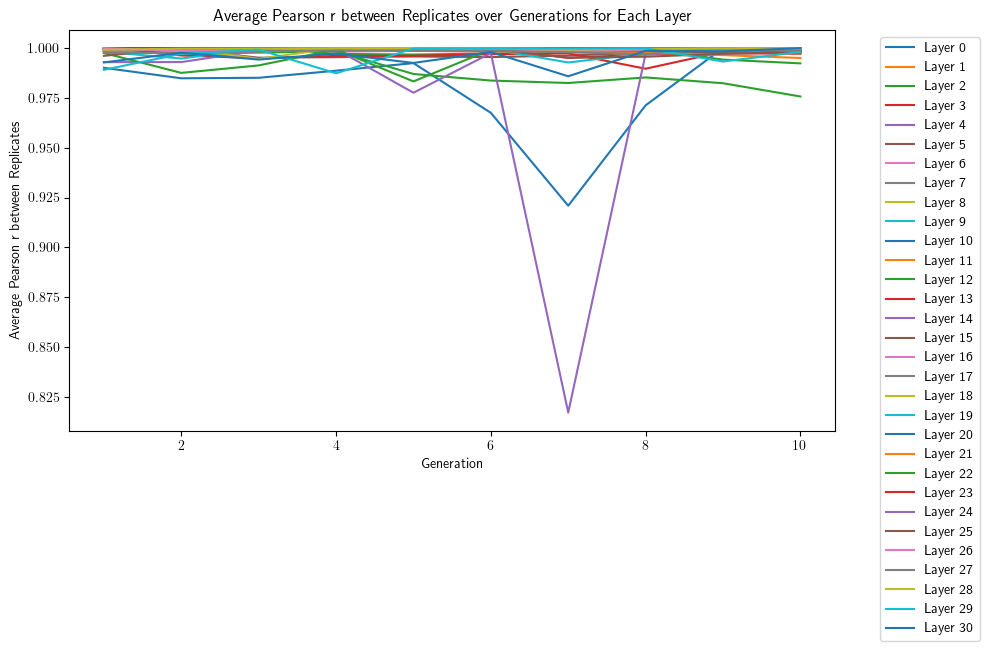

In [62]:
# Plot the layer results
plt.figure(figsize=(10, 6))
for layer in range(n_layers):
    plt.plot(range(1, n_gens + 1), layer_pearson_results[layer], label=f'Layer {layer}')
plt.xlabel('Generation')
plt.ylabel('Average Pearson r between Replicates')
plt.title('Average Pearson r between Replicates over Generations for Each Layer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [63]:
# save layer results to pickle
with open(pwd + '/layer_pearson_results.pkl', 'wb') as f:
    pickle.dump(layer_pearson_results, f)

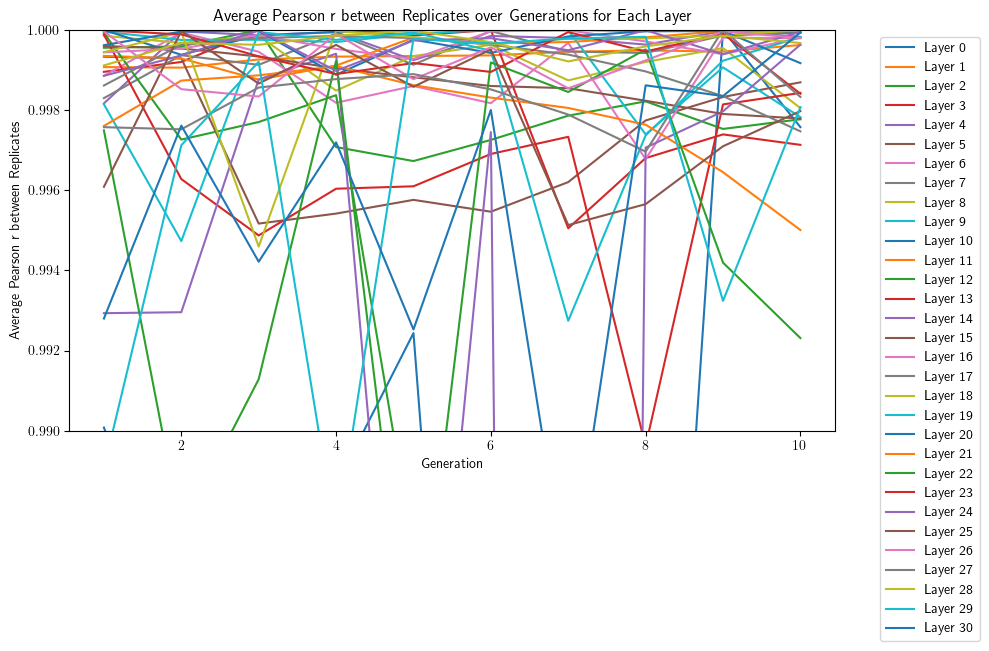

In [65]:
# Plot the layer results
plt.figure(figsize=(10, 6))
for layer in range(n_layers):
    plt.plot(range(1, n_gens + 1), layer_pearson_results[layer], label=f'Layer {layer}')
plt.xlabel('Generation')
plt.ylabel('Average Pearson r between Replicates')
plt.title('Average Pearson r between Replicates over Generations for Each Layer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.ylim(0.99, 1.0)

plt.show()

## Simulations with a few really strong and the rest weak

In [75]:
# Lets run the whole simulation at every layer and calculate the average pearson r at every generation
newsim_pearson_results = {}
n_layers = 31
n_gens = 10
n_reps = 3

for layer in range(n_layers):
    print(f"Running layer {layer}...")
    df_selection, initial_counts = get_df_selection(random_seed=42, selected_layer=layer)
    
    # Generate some random selection coefficients for the 640 dimensions
    np.random.seed(42)
    #selection_coefficients = np.random.normal(loc=0.0, scale=0.1, size=640)
    # find the range of each embedding dimension
    embedding_matrix = np.vstack(df_selection['Embedding'].values)
    embedding_ranges = embedding_matrix.max(axis=0) - embedding_matrix.min(axis=0)
    # Find the index of the highest, middle, and lowest range dimensions
    sorted_indices = np.argsort(embedding_ranges)
    high_range_idx = sorted_indices[-1]
    mid_range_idx = sorted_indices[len(sorted_indices) // 2]
    low_range_idx = sorted_indices[0]
    # Set -100 to every dimension except these three
    selection_coefficients = np.zeros(640)
    selection_coefficients[high_range_idx] = 10.0
    selection_coefficients[mid_range_idx] = 10.0
    selection_coefficients[low_range_idx] = 10.0
    
    
    print("Running simulation...")
    generation_counts = run_simulation(selection_coefficients, initial_counts, n_gens=30)
    
    layer_results = []
    
    for gen in range(1, n_gens + 1, 2):
        print(f"  Analyzing generation {gen}...")
        test_path = pwd + f"/simulations/layer_{layer}_gen_{gen}/"
        data = run_inference_calcs_sims(df_selection, generation_counts[:gen + 1], test_path)
        found_sel_coeffs = data[2]
        
        # Calculate pearson r for each replicate comparison
        rep_pearsons = []
        for rep1 in range(3):
            for rep2 in range(rep1 + 1, 3):
                x = found_sel_coeffs[rep1]
                y = found_sel_coeffs[rep2]
                r_pearson = np.corrcoef(x, y)[0, 1]
                rep_pearsons.append(r_pearson)
        
        layer_results.append(np.mean(rep_pearsons))
    
    newsim_pearson_results[layer] = layer_results

Running layer 0...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3...
  Analyzing generation 5...
  Analyzing generation 7...
  Analyzing generation 9...
Running layer 1...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3...
  Analyzing generation 5...
  Analyzing generation 7...
  Analyzing generation 9...
Running layer 2...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3...
  Analyzing generation 5...
  Analyzing generation 7...
  Analyzing generation 9...
Running layer 3...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3...
  Analyzing generation 5...
  Analyzing generation 7...
  Analyzing generation 9...
Running layer 4...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3...
  Analyzing generation 5...
  Analyzing generation 7...
  Analyzing generation 9...
Running layer 5...
Running simulation...
  Analyzing generation 1...
  Analyzing generation 3..

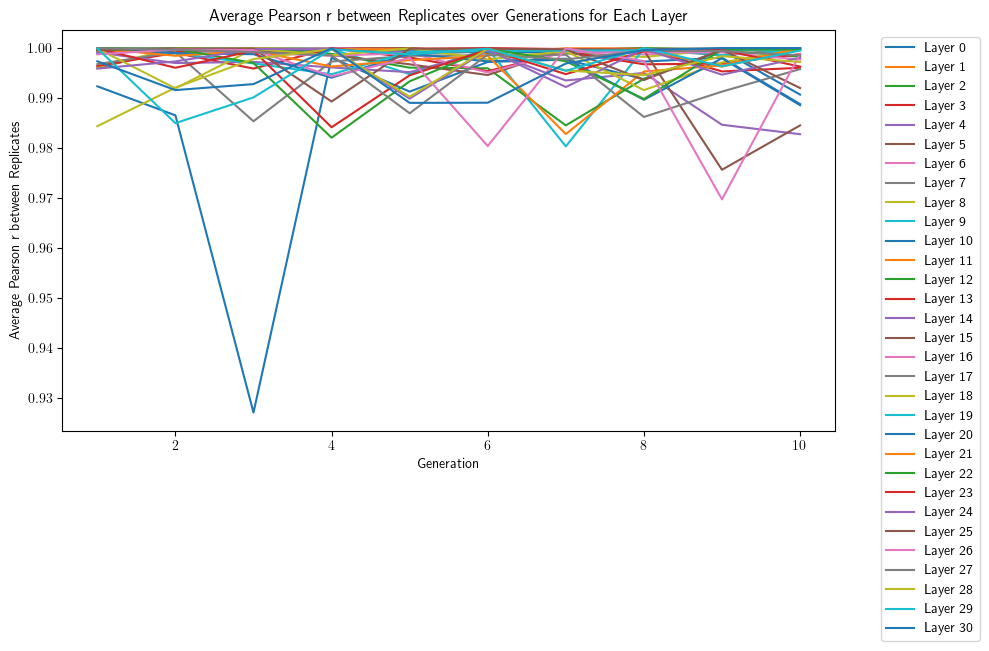

In [ ]:
# Plot the layer results
plt.figure(figsize=(10, 6))
for layer in range(n_layers):
    plt.plot(range(1, n_gens + 1), newsim_pearson_results[layer], label=f'Layer {layer}')
plt.xlabel('Generation')
plt.ylabel('Average Pearson r between Replicates')
plt.title('Average Pearson r between Replicates over Generations for Each Layer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.ylim(0.99, 1.0)

plt.show()

## Looking at the ranking of selection coefficients found versus real

In [ ]:
# What data do I want to save?
# The selections of every coefficients, and the inferred selections of every coefficient across layer and generation
detailed_selection_results = {}
selection_coefficients_all = {}

n_layers = 31
n_gens = 10
n_reps = 3

for layer in range(n_layers):
    print(f"Running layer {layer}...")
    df_selection, initial_counts = get_df_selection(random_seed=42, selected_layer=layer)
    
    # Generate some random selection coefficients for the 640 dimensions
    np.random.seed(42)
    #selection_coefficients = np.random.normal(loc=0.0, scale=0., size=640)
    # find the range of each embedding dimension
    np.random.seed(42)
    selection_coefficients = np.random.normal(loc=0.0, scale=1.0, size=640)
    #selection_coefficients = np.abs(selection_coefficients)  # Ensure non-negative for this example
    selection_coefficients_all[layer] = selection_coefficients
    
    print("Running simulation...")
    generation_counts = run_simulation(selection_coefficients, initial_counts, n_gens=30)
    layer_results = []
    
    for gen in range(1, n_gens + 1, 2):
        print(f"  Analyzing generation {gen}...")
        test_path = pwd + f"/simulations/layer_{layer}_gen_{gen}/"
        data = run_inference_calcs_sims(df_selection, generation_counts[:gen + 1], test_path)
        found_sel_coeffs = data[2]
        layer_results.append(found_sel_coeffs)
    
    detailed_selection_results[layer] = layer_results

In [ ]:
# Now save the detailed selection results and selection coefficients all to pickle
with open(pwd + '/detailed_selection_results.pkl', 'wb') as f:
    pickle.dump(detailed_selection_results, f)
with open(pwd + '/selection_coefficients_all.pkl', 'wb') as f:
    pickle.dump(selection_coefficients_all, f)

In [ ]:
# Now compare the ranks of the true vs inferred selection coefficients for each layer and generation
from scipy.stats import rankdata
detailed_rank_results = {}
for layer in range(n_layers):
    layer_rank_results = []
    true_selection = selection_coefficients_all[layer]
    for gen in range(0, n_gens, 2):
        inferred_selection = detailed_selection_results[layer][gen]
        rep_rank_pearsons = []
        for rep in range(n_reps):
            true_ranks = rankdata(true_selection)
            inferred_ranks = rankdata(inferred_selection[rep])
            r_pearson = np.corrcoef(true_ranks, inferred_ranks)[0, 1]
            rep_rank_pearsons.append(r_pearson)
        layer_rank_results.append(np.mean(rep_rank_pearsons))
    detailed_rank_results[layer] = layer_rank_results
    
# Plot the layer results
plt.figure(figsize=(10, 6))
for layer in range(n_layers):
    plt.plot(range(1, n_gens + 1, 2), detailed_rank_results[layer], label=f'Layer {layer}')
plt.xlabel('Generation')
plt.ylabel('Average Rank Pearson r between True and Inferred')
plt.title('Average Rank Pearson r between True and Inferred Selection Coefficients over Generations for Each Layer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()